# REDES NEURONALES

---



En esta actividad vamos a utilizar una red neuronal para clasificar imágenes de dígitos del 0 al 9 escritos a mano. Para ello, utilizaremos Keras con TensorFlow.

El dataset a utilizar es MNIST, una base de datos constituida por (como no) imágenes de dígitos escritos a mano. Este dataset es ampliamente utilizado en docencia como punto de entrada al entrenamiento de redes neuronales y otros, pero también es muy utilizado en trabajos reales de investigación para el entrenamiento de imágenes. Puedes consultar más información sobre el dataset en [este enlace](https://es.wikipedia.org/wiki/Base_de_datos_MNIST).

El código utilizado para contestar tiene que quedar claramente reflejado en el Notebook. Puedes crear nuevas celdas si así lo deseas para estructurar tu código y sus salidas. A la hora de entregar el notebook, **asegúrate de que los resultados de ejecutar tu código han quedado guardados y que son perfectamente visibles en la versión PDF que debes entregar adjunta**. Por ejemplo, a la hora de entrenar una red neuronal tiene que verse claramente un log de los resultados de cada epoch.

In [1]:
from keras.datasets.mnist import load_data
import tensorflow as tf
import matplotlib.pyplot as plt

Tenemos la suerte de que el dataset MNIST, el que vamos a utilizar en esta actividad, está guardado en Keras, por lo que podemos utilizarlo sin necesidad de buscar el dataset de forma externa.

In [2]:
mnist = tf.keras.datasets.fashion_mnist

Llamar a **load_data** en este dataset nos dará dos conjuntos de dos listas, estos serán los valores de entrenamiento y prueba para los gráficos que contienen los dígitos y sus etiquetas.

Nota: Aunque en esta actividad lo veis de esta forma, también lo vais a poder encontrar como 4 variables de esta forma: training_images, training_labels, test_images, test_labels = mnist.load_data()

In [3]:
(training_images, training_labels), (test_images, test_labels) = load_data()

Antes de continuar vamos a dar un vistazo a nuestro dataset, para ello vamos a ver una imagen de entrenamiento y su etiqueta o clase.

5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0 

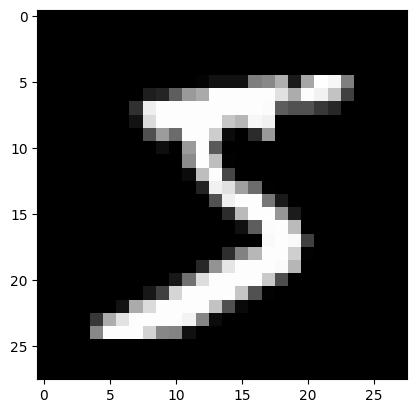

In [4]:
import numpy as np
np.set_printoptions(linewidth=200)
plt.imshow(training_images[0], cmap="gray") # recordad que siempre es preferible trabajar en blanco y negro
#
print(training_labels[0])
print(training_images[0])

## 1. Información sobre el dataset

Una vez tenemos los datos cargados en memoria, vamos a obtener información sobre los mismos.

**Pregunta 1.1 *(0.25 puntos)*** ¿Cuántas imágenes hay de *training* y de *test*? ¿Qué tamaño tienen las imágenes?

In [5]:
import random
import time
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Guardo copias antes de transformar los datos para poder consultar el formato original.
training_images_raw = training_images.copy()
test_images_raw = test_images.copy()
training_labels_raw = training_labels.copy()
test_labels_raw = test_labels.copy()

print("Imágenes de training:", training_images.shape[0])
print("Imágenes de test:", test_images.shape[0])
print("Tamaño de cada imagen de training:", training_images.shape[1:])
print("Tamaño de cada imagen de test:", test_images.shape[1:])
print("Tipo de dato de X:", training_images.dtype)
print("Tipo de dato de y:", training_labels.dtype)


Imágenes de training: 60000
Imágenes de test: 10000
Tamaño de cada imagen de training: (28, 28)
Tamaño de cada imagen de test: (28, 28)
Tipo de dato de X: uint8
Tipo de dato de y: uint8


Hay **60.000 imágenes de entrenamiento** y **10.000 imágenes de test**. Cada imagen tiene un tamaño de **28 x 28 píxeles**, por lo que cada ejemplo contiene 784 valores de intensidad antes de aplicar ningún preprocesado. Esos valores son números enteros entre 0 y 255.


**Pregunta 1.2 *(0.25 puntos)*** Realizar una exploración de las variables que contienen los datos. Describir en qué consiste un example del dataset (qué información se guarda en cada imagen) y describir qué contiene la información en y.

Rango de valores en X_train: 0 - 255
Rango de valores en X_test: 0 - 255
Forma de una imagen individual: (28, 28)
Etiqueta asociada a esa imagen: 5


,dígito,n_imágenes_training
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


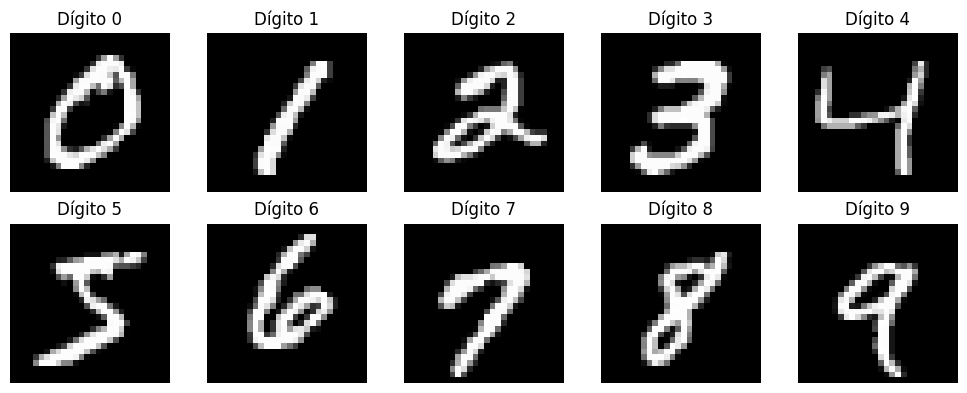

In [6]:
print("Rango de valores en X_train:", training_images_raw.min(), "-", training_images_raw.max())
print("Rango de valores en X_test:", test_images_raw.min(), "-", test_images_raw.max())
print("Forma de una imagen individual:", training_images_raw[0].shape)
print("Etiqueta asociada a esa imagen:", training_labels_raw[0])

label_counts = pd.Series(training_labels_raw).value_counts().sort_index()
display(pd.DataFrame({"dígito": label_counts.index, "n_imágenes_training": label_counts.values}))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(training_labels_raw == digit)[0][0]
    ax.imshow(training_images_raw[idx], cmap="gray")
    ax.set_title(f"Dígito {digit}")
    ax.axis("off")
plt.tight_layout()
plt.show()


Cada ejemplo del dataset es una imagen en escala de grises de 28 x 28 píxeles. La variable `X` guarda una matriz por imagen; cada posición de esa matriz representa la intensidad de un píxel. La variable `y` contiene la clase correcta de cada imagen, es decir, un número entero entre 0 y 9 que indica qué dígito manuscrito aparece.


## 2. Normalización y preprocesado de los datos

**Pregunta 2.1 (0.25 puntos)** Habreis notado que todos los valores numericos están entre 0 y 255. Si estamos entrenando una red neuronal, una buena practica es transformar todos los valores entre 0 y 1, un proceso llamado "normalización" y afortunadamente en Python es fácil normalizar una lista. ¿Cómo lo podemos hacer?

In [7]:
training_images = training_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print("Rango tras normalizar X_train:", training_images.min(), "-", training_images.max())
print("Rango tras normalizar X_test:", test_images.min(), "-", test_images.max())


Rango tras normalizar X_train: 0.0 - 1.0
Rango tras normalizar X_test: 0.0 - 1.0


**Pregunta 2.2 (0.25 puntos)** Utiliza la función ***reshape*** de Numpy para convertir las imágenes en vectores de características de un tamaño de (N, 784). Explica con tus palabras por qué es necesario hacer esto.



In [8]:
X_train = training_images.reshape((training_images.shape[0], 28 * 28))
X_test = test_images.reshape((test_images.shape[0], 28 * 28))

print("Forma original de entrenamiento:", training_images.shape)
print("Forma vectorizada de entrenamiento:", X_train.shape)
print("Forma original de test:", test_images.shape)
print("Forma vectorizada de test:", X_test.shape)


Forma original de entrenamiento: (60000, 28, 28)
Forma vectorizada de entrenamiento: (60000, 784)
Forma original de test: (10000, 28, 28)
Forma vectorizada de test: (10000, 784)


**Respuesta a la pregunta 2.2**:

Para un perceptrón multicapa con capas `Dense`, cada ejemplo debe entrar como un vector de características. Una imagen de 28 x 28 píxeles se transforma en un vector de 784 posiciones para que cada neurona de la primera capa densa pueda recibir todos los píxeles como variables de entrada. Si se utilizara una red convolucional, no haría falta aplanar manualmente las imágenes, pero en la actividad el objetivo es trabajar con un MLP.


**Pregunta 2.3 (0.25 puntos)** Para facilitar el desarrollo de la actividad, vamos a expresar las etiquetas así:

In [9]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

Muestra cómo son ahora los datos, como resultado de este cambio y también de los realizados en las dos preguntas anteriores. Debate cómo se beneficiará la red neuronal de todos estos cambios.

In [10]:
y_train = training_labels
y_test = test_labels

print("X_train:", X_train.shape, X_train.dtype)
print("X_test:", X_test.shape, X_test.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("y_test:", y_test.shape, y_test.dtype)
print("Etiqueta original del primer ejemplo:", training_labels_raw[0])
print("Etiqueta one-hot del primer ejemplo:", y_train[0])
print("Primeros 12 valores normalizados del primer vector:")
print(X_train[0][:12])


X_train: (60000, 784) float32
X_test: (10000, 784) float32
y_train: (60000, 10) float64
y_test: (10000, 10) float64
Etiqueta original del primer ejemplo: 5
Etiqueta one-hot del primer ejemplo: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Primeros 12 valores normalizados del primer vector:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Respuesta a la pregunta 2.3:

Después del preprocesado, cada imagen queda como un vector de 784 características con valores entre 0 y 1, y cada etiqueta queda como un vector one-hot de 10 posiciones. La normalización ayuda a que el entrenamiento sea más estable, porque todos los píxeles quedan en una escala parecida. La vectorización adapta las imágenes a las capas densas y el one-hot encoding permite usar `categorical_crossentropy`, comparando las probabilidades predichas por `softmax` con la clase real.


## 3. Creación del Modelo

Ahora vamos a definir el modelo, pero antes vamos a repasar algunos comandos y conceptos muy útiles:
* **Sequential**: Eso define una SECUENCIA de capas en la red neuronal
* **Dense**: Añade una capa de neuronas
* **Flatten**: ¿Recuerdas cómo eran las imágenes cuando las imprimiste para poder verlas? Un cuadrado, Flatten toma ese cuadrado y lo convierte en un vector de una dimensión.

Cada capa de neuronas necesita una función de activación. Normalmente se usa la función relu en las capas intermedias y softmax en la ultima capa (en problemas de clasificación de más de dos items)
* **Relu** significa que "Si X>0 devuelve X, si no, devuelve 0", así que lo que hace es pasar sólo valores 0 o mayores a la siguiente capa de la red.
* **Softmax** toma un conjunto de valores, y escoge el más grande.

 **Pregunta 3.1 (0.5 puntos)**. Utilizando Keras, y preparando los datos de X e Y como fuera necesario, define y entrena una red neuronal que sea capaz de clasificar imágenes de MNIST con las siguientes características:

* Una capa de entrada del tamaño adecuado.
* Una capa oculta de 512 neuronas.
* Una capa final con 10 salidas.

In [11]:
def reset_seeds(seed=SEED):
    """Reinicia las semillas para que las comparaciones sean más reproducibles."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# Esta función evita repetir mucho código en los apartados comparativos.
# Mantiene una misma base de MLP y permite cambiar solo el elemento que se quiere estudiar.
def create_mlp(
    hidden_units=512,
    activation="relu",
    output_units=10,
    initializer="glorot_uniform",
    input_dim=784,
    hidden_layers=None,
    dropout_rate=0.0,
    l2_value=0.0,
    batch_norm=False,
):
    if hidden_layers is None:
        hidden_layers = [hidden_units]

    model_layers = [layers.Input(shape=(input_dim,))]
    for units in hidden_layers:
        model_layers.append(
            layers.Dense(
                units,
                kernel_initializer=initializer,
                kernel_regularizer=regularizers.l2(l2_value) if l2_value else None,
                use_bias=not batch_norm,
            )
        )
        if batch_norm:
            model_layers.append(layers.BatchNormalization())
        model_layers.append(layers.Activation(activation))
        if dropout_rate:
            model_layers.append(layers.Dropout(dropout_rate))
    model_layers.append(layers.Dense(output_units, activation="softmax"))
    return keras.Sequential(model_layers)


model = create_mlp(hidden_units=512)
print("Modelo base creado con entrada de 784 características, capa oculta de 512 neuronas y salida de 10 clases.")


Modelo base creado con entrada de 784 características, capa oculta de 512 neuronas y salida de 10 clases.


**Pregunta 3.2 (0.25 puntos)**: ¿crees conveniente utilizar una capa flatten en este caso? Motiva tu respuesta.



In [12]:
model_with_flatten = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

print("Modelo alternativo con Flatten si se alimentan imágenes 28x28 directamente:")


Modelo alternativo con Flatten si se alimentan imágenes 28x28 directamente:


**Respuesta a la pregunta 3.2**:

En el modelo principal no es necesario incluir una capa `Flatten`, porque en el apartado anterior ya se ha aplicado `reshape` y cada imagen entra como un vector de 784 valores. Sí sería conveniente usar `Flatten` si quisiéramos pasar al modelo las imágenes con su forma original `(28, 28)`, ya que una capa `Dense` necesita recibir un vector por cada ejemplo.


**Pregunta 3.3 (0.25 puntos)**: Utiliza la función summary() para mostrar la estructura de tu modelo.

In [13]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## 4: Compilación y entrenamiento

**Pregunta 4.1 (0.5 puntos)**: Compila tu modelo. Utiliza ***categorical_crossentropy*** como función de pérdida, ***Adam*** como optimizador, y monitoriza la ***tasa de acierto*** durante el entrenamiento. Explica qué hace cada cosa en la compilación.

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
print("Modelo compilado.")


Modelo compilado.


**Respuesta a la pregunta 4.1**:

La función de pérdida `categorical_crossentropy` mide la diferencia entre la etiqueta real en formato one-hot y las probabilidades que produce `softmax`; por eso encaja con un problema multiclase como MNIST. El optimizador `Adam` ajusta el aprendizaje de forma adaptativa y suele funcionar bien sin tener que probar demasiados valores iniciales. La métrica `accuracy` indica qué proporción de imágenes se clasifican correctamente, así que permite seguir el entrenamiento de una forma bastante intuitiva.


**Pregunta 4.2 (0.5 puntos)**: Utiliza la función ***fit()*** para entrenar tu modelo. Para ayudarte en tu primer entrenamiento, utiliza estos valores:
*   epochs = 5
*   batch_size = 32
*   validation_split = 0.25



Epoch 1/5


1407/1407 - 3s - 2ms/step - accuracy: 0.9342 - loss: 0.2253 - val_accuracy: 0.9611 - val_loss: 0.1318


Epoch 2/5


1407/1407 - 2s - 2ms/step - accuracy: 0.9730 - loss: 0.0878 - val_accuracy: 0.9651 - val_loss: 0.1123


Epoch 3/5


1407/1407 - 2s - 2ms/step - accuracy: 0.9849 - loss: 0.0526 - val_accuracy: 0.9675 - val_loss: 0.1081


Epoch 4/5


1407/1407 - 2s - 2ms/step - accuracy: 0.9911 - loss: 0.0326 - val_accuracy: 0.9690 - val_loss: 0.1139


Epoch 5/5


1407/1407 - 2s - 2ms/step - accuracy: 0.9942 - loss: 0.0219 - val_accuracy: 0.9731 - val_loss: 0.1042


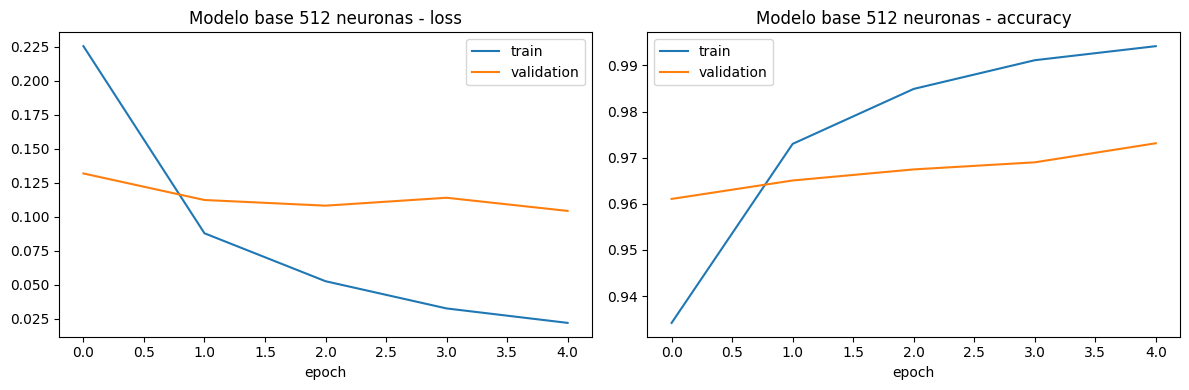

,modelo,val_accuracy_final,val_loss_final,test_accuracy,test_loss,tiempo_s
0,"512 neuronas, 5 epochs",0.973133,0.104241,0.9759,0.082602,12.558183


In [15]:
def plot_history(history, title):
    """Representa la evolución de pérdida y accuracy para detectar mejora u overfitting."""
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="validation")
    axes[0].set_title(f"{title} - loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="validation")
    axes[1].set_title(f"{title} - accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def train_model(model_to_train, epochs=5, batch_size=32, validation_split=0.25, optimizer=None, verbose=0, callbacks=None):
    """Compila, entrena y evalúa un modelo manteniendo el mismo procedimiento de comparación."""
    if optimizer is None:
        optimizer = keras.optimizers.Adam()
    model_to_train.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    start = time.time()
    history = model_to_train.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=verbose,
        callbacks=callbacks,
    )
    elapsed = time.time() - start
    test_loss, test_acc = model_to_train.evaluate(X_test, y_test, verbose=0)
    return history, elapsed, test_loss, test_acc


# Primer entrenamiento de referencia con los valores pedidos en el enunciado.
history_base, time_base, test_loss_base, test_acc_base = train_model(
    model, epochs=5, batch_size=32, validation_split=0.25, verbose=2
)
plot_history(history_base, "Modelo base 512 neuronas")

pd.DataFrame([{
    "modelo": "512 neuronas, 5 epochs",
    "val_accuracy_final": history_base.history["val_accuracy"][-1],
    "val_loss_final": history_base.history["val_loss"][-1],
    "test_accuracy": test_acc_base,
    "test_loss": test_loss_base,
    "tiempo_s": time_base,
}])


# 5: Impacto al variar el número de neuronas en las capas ocultas

En este ejercicio vamos a experimentar con nuestra red neuronal cambiando el numero de neuronas por 512 y por otros valores. Para ello, utiliza la red neuronal de la pregunta 3, y su capa oculta cambia el número de neuronas:

* **216 neuronas en la capa oculta
* **1024 neuronas en la capa oculta

y entrena la red en ambos casos.



In [16]:
hidden_results = []

# Se entrena una versión más pequeña para medir si reduce demasiado la capacidad del modelo.
reset_seeds()
tf.keras.backend.clear_session()
model_216 = create_mlp(hidden_units=216)
history_216, elapsed_216, test_loss_216, test_acc_216 = train_model(
    model_216, epochs=5, batch_size=32, validation_split=0.25
)
hidden_results.append({
    "neuronas": 216,
    "params": model_216.count_params(),
    "val_accuracy": history_216.history["val_accuracy"][-1],
    "test_accuracy": test_acc_216,
    "val_loss": history_216.history["val_loss"][-1],
    "tiempo_s": elapsed_216,
})

pd.DataFrame(hidden_results)


,neuronas,params,val_accuracy,test_accuracy,val_loss,tiempo_s
0,216,171730,0.969667,0.9744,0.1073,8.051506


,neuronas,params,val_accuracy,test_accuracy,val_loss,tiempo_s
0,216,171730,0.969667,0.9744,0.107300,8.051506
1,1024,814090,0.972600,0.9764,0.105779,20.179033


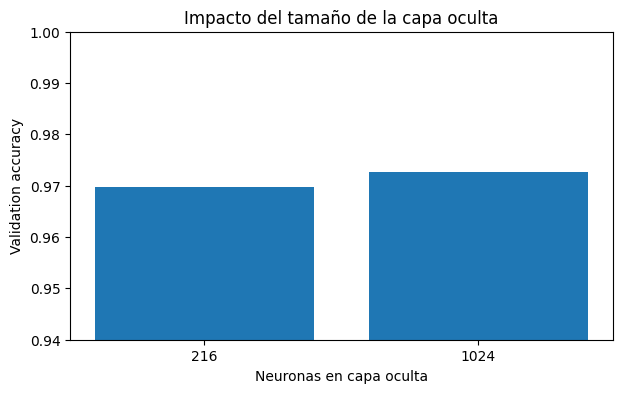

In [17]:
# Se entrena una versión más grande para comprobar si añadir parámetros mejora la clasificación.
reset_seeds()
tf.keras.backend.clear_session()
model_1024 = create_mlp(hidden_units=1024)
history_1024, elapsed_1024, test_loss_1024, test_acc_1024 = train_model(
    model_1024, epochs=5, batch_size=32, validation_split=0.25
)
hidden_results.append({
    "neuronas": 1024,
    "params": model_1024.count_params(),
    "val_accuracy": history_1024.history["val_accuracy"][-1],
    "test_accuracy": test_acc_1024,
    "val_loss": history_1024.history["val_loss"][-1],
    "tiempo_s": elapsed_1024,
})

hidden_results_df = pd.DataFrame(hidden_results)
display(hidden_results_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(hidden_results_df["neuronas"].astype(str), hidden_results_df["val_accuracy"])
ax.set_ylim(0.94, 1.0)
ax.set_xlabel("Neuronas en capa oculta")
ax.set_ylabel("Validation accuracy")
ax.set_title("Impacto del tamaño de la capa oculta")
plt.show()


**Pregunta 5.1 (0.5 puntos)**: ¿Cual es el impacto que tiene la red neuronal?

Respuesta a la pregunta 5.1:

Los resultados muestran que pasar de 216 a 1024 neuronas aumenta mucho el número de parámetros y el tiempo de entrenamiento, pero la mejora en `validation accuracy` es pequeña. Esto es coherente con MNIST: es un problema relativamente limpio y una red densa de tamaño medio ya puede aprender patrones útiles. Por tanto, más neuronas aportan algo más de capacidad, pero no garantizan una mejora proporcional y pueden aumentar el riesgo de sobreajuste si se sigue ampliando la red sin regularización.


# 6: Número de neuronas de la capa de salida
Considerad la capa final, la de salida de la red neuronal de la pregunta 3.

**Pregunta 6.1 (0.25 puntos)**: ¿Por qué son 10 las neuronas de la última capa?

**Pregunta 6.2 (0.25 puntos)**: ¿Qué pasaría si tuvieras una cantidad diferente a 10?

Por ejemplo, intenta entrenar la red con 5, para ello utiliza la red neuronal de la pregunta 1 y cambia a 5 el número de neuronas en la última capa.

In [18]:
reset_seeds()
tf.keras.backend.clear_session()
model_5_outputs = create_mlp(hidden_units=512, output_units=5)
model_5_outputs.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

try:
    model_5_outputs.fit(X_train, y_train, epochs=1, batch_size=128, validation_split=0.25, verbose=0)
except Exception as exc:
    print("No se puede entrenar correctamente con 5 neuronas de salida y etiquetas one-hot de 10 clases.")
    print("Tipo de error:", type(exc).__name__)
    print("Mensaje:", str(exc).split("\n")[0])


No se puede entrenar correctamente con 5 neuronas de salida y etiquetas one-hot de 10 clases.
Tipo de error: ValueError
Mensaje: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 10), output.shape=(None, 5)


Respuesta a la pregunta 6.1:

La última capa tiene 10 neuronas porque MNIST tiene 10 clases posibles: los dígitos del 0 al 9. Cada neurona de salida representa la probabilidad estimada de una clase. Con `softmax`, la red devuelve una distribución de probabilidad sobre esas 10 clases y se elige la clase con mayor probabilidad.


Respuesta a la pregunta 6.2:

Si la capa final tuviera una cantidad distinta de 10 neuronas, la salida del modelo no coincidiría con el problema. Con 5 neuronas no se pueden representar las 10 clases y, además, aparece una incompatibilidad de dimensiones al comparar la salida `(N, 5)` con las etiquetas one-hot `(N, 10)`. Si hubiera más de 10 neuronas, existirían clases de salida sin significado en el dataset, lo que también sería un diseño incorrecto.


# 7: Aumento de epoch y su efecto en la red neuronal
En este ejercicio vamos a ver el impacto de aumentar los epoch en el entrenamiento. Usando la red neuronal de la pregunta 3:

**Pregunta 7.1 (0.25 puntos)**
* Intentad 15 epoch para su entrenamiento, probablemente obtendras un modelo con una pérdida mucho mejor que el que tiene 5.

**Pregunta 7.2 (0.25 puntos)**
* Intenta ahora con 30 epoch para su entrenamiento.

**Pregunta 7.3 (0.25 puntos)**
* ¿Qué está pasando en la pregunta anterior? Explica tu respuesta y da el nombre de este efecto si lo conoces.

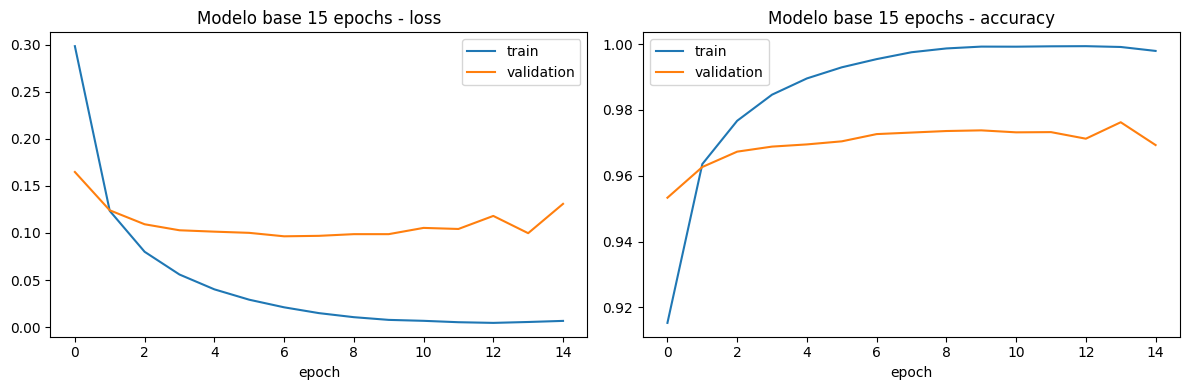

,epochs,val_accuracy_final,val_loss_final,test_accuracy,test_loss,tiempo_s
0,15,0.969333,0.130926,0.9748,0.107547,13.264718


In [19]:
# Se aumenta a 15 epochs para observar si el modelo sigue mejorando al entrenar más tiempo.
reset_seeds()
tf.keras.backend.clear_session()
model_15 = create_mlp(hidden_units=512)
history_15, time_15, test_loss_15, test_acc_15 = train_model(
    model_15, epochs=15, batch_size=128, validation_split=0.25
)
plot_history(history_15, "Modelo base 15 epochs")

pd.DataFrame([{
    "epochs": 15,
    "val_accuracy_final": history_15.history["val_accuracy"][-1],
    "val_loss_final": history_15.history["val_loss"][-1],
    "test_accuracy": test_acc_15,
    "test_loss": test_loss_15,
    "tiempo_s": time_15,
}])


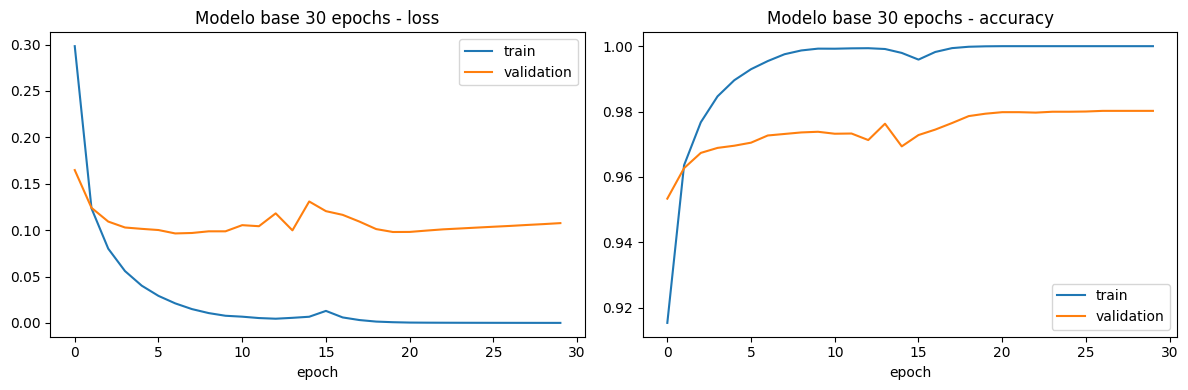

,epochs,val_accuracy_final,val_loss_final,test_accuracy,test_loss,tiempo_s
0,5,0.973133,0.104241,0.9759,0.082602,12.558183
1,15,0.969333,0.130926,0.9748,0.107547,13.264718
2,30,0.980200,0.107605,0.9830,0.087178,29.681061


In [20]:
# Con 30 epochs se comprueba si el entrenamiento prolongado mejora o empieza a sobreajustar.
reset_seeds()
tf.keras.backend.clear_session()
model_30 = create_mlp(hidden_units=512)
history_30, time_30, test_loss_30, test_acc_30 = train_model(
    model_30, epochs=30, batch_size=128, validation_split=0.25
)
plot_history(history_30, "Modelo base 30 epochs")

epochs_results_df = pd.DataFrame([
    {
        "epochs": 5,
        "val_accuracy_final": history_base.history["val_accuracy"][-1],
        "val_loss_final": history_base.history["val_loss"][-1],
        "test_accuracy": test_acc_base,
        "test_loss": test_loss_base,
        "tiempo_s": time_base,
    },
    {
        "epochs": 15,
        "val_accuracy_final": history_15.history["val_accuracy"][-1],
        "val_loss_final": history_15.history["val_loss"][-1],
        "test_accuracy": test_acc_15,
        "test_loss": test_loss_15,
        "tiempo_s": time_15,
    },
    {
        "epochs": 30,
        "val_accuracy_final": history_30.history["val_accuracy"][-1],
        "val_loss_final": history_30.history["val_loss"][-1],
        "test_accuracy": test_acc_30,
        "test_loss": test_loss_30,
        "tiempo_s": time_30,
    },
])
display(epochs_results_df)


Respuesta a las preguntas 7.1, 7.2 y 7.3:

La comparación entre 5, 15 y 30 epochs muestra que entrenar durante más tiempo no mejora siempre de forma lineal. En esta ejecución, el modelo con 15 epochs no supera al de 5 en validación, mientras que el de 30 epochs sí obtiene una mejor `validation accuracy` y también una mejor accuracy en test. Aun así, la pérdida de validación no baja de manera proporcional, lo que indica que conviene vigilar las curvas y no elegir el número de epochs solo por intuición. Por este motivo, la conclusión del apartado es que aumentar epochs puede ayudar, pero debe combinarse con observación de la validación o con `EarlyStopping` para evitar entrenar de más.


# 8: Early stop
En el ejercicio anterior, cuando entrenabas con epoch extras, tenías un problema en el que tu pérdida podía cambiar. Puede que te haya llevado un poco de tiempo esperar a que el entrenamiento lo hiciera,  y puede que hayas pensado "¿no estaría bien si pudiera parar el entrenamiento cuando alcance un valor deseado?", es decir, una precisión del 85% podría ser suficiente para ti, y si alcanzas eso después de 3 epoch, ¿por qué sentarte a esperar a que termine muchas más épocas? Como cualquier otro programa existen formas de parar la ejecución

A partir del código de ejemplo, hacer una nueva función que tenga en cuenta la perdida (loss) y que pueda parar el código para evitar que ocurra el efeto secundario que vimos en el ejercicio 5.

In [21]:
### Ejemplo de código

class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.85):
              print("\nAlcanzado el 85% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

**Pregunta 8.1. *(0.75 puntos)***: Consulta la documentación de Keras y aprende cómo podemos utilizar Early stop en nuestro modelos.

Epoch 1/50


352/352 - 1s - 3ms/step - accuracy: 0.9153 - loss: 0.2983 - val_accuracy: 0.9533 - val_loss: 0.1648


Epoch 2/50


352/352 - 1s - 2ms/step - accuracy: 0.9636 - loss: 0.1235 - val_accuracy: 0.9627 - val_loss: 0.1241


Epoch 3/50


...

352/352 - 1s - 3ms/step - accuracy: 0.9987 - loss: 0.0106 - val_accuracy: 0.9736 - val_loss: 0.0988


Epoch 10/50


352/352 - 1s - 3ms/step - accuracy: 0.9992 - loss: 0.0078 - val_accuracy: 0.9738 - val_loss: 0.0988


Epoch 10: early stopping


Restoring model weights from the end of the best epoch: 7.


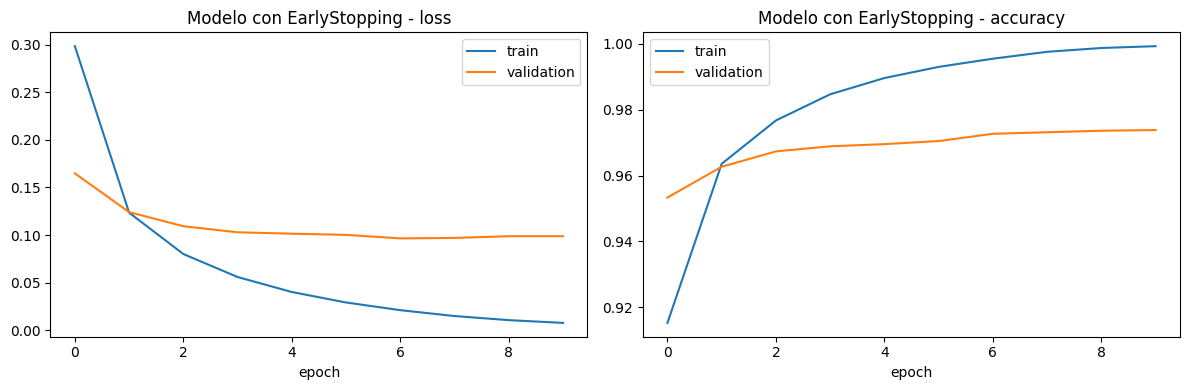

Entrenamiento detenido tras 10 epochs.
Mejor val_loss: 0.0965
Test accuracy tras restaurar los mejores pesos: 0.9783


In [22]:
reset_seeds()
tf.keras.backend.clear_session()

# EarlyStopping detiene el entrenamiento cuando la validación deja de mejorar.
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1,
)

model_early = create_mlp(hidden_units=512)
history_early, time_early, test_loss_early, test_acc_early = train_model(
    model_early,
    epochs=50,
    batch_size=128,
    validation_split=0.25,
    callbacks=[early_stop],
    verbose=2,
)
plot_history(history_early, "Modelo con EarlyStopping")

print(f"Entrenamiento detenido tras {len(history_early.history['loss'])} epochs.")
print(f"Mejor val_loss: {min(history_early.history['val_loss']):.4f}")
print(f"Test accuracy tras restaurar los mejores pesos: {test_acc_early:.4f}")


## 9. Unidades de activación

En este ejercicio, vamos a evaluar la importancia de utilizar las unidades de activación adecuadas. Como hemos visto en clase, funciones de activación como sigmoid han dejado de utilizarse en favor de otras unidades como ReLU.

**Pregunta 9.1 *(0.75 puntos)***: Utilizando la red realizada en el ejercicio 3, escribir un breve análisis comparando la utilización de unidades sigmoid y ReLU (por ejemplo, se pueden comentar aspectos como velocidad de convergencia, métricas obtenidas...). Explicar por qué pueden darse estas diferencias. Opcionalmente, comparar con otras activaciones disponibles en Keras.

*Pista: Usando redes más grandes se hace más sencillo apreciar las diferencias. Es mejor utilizar al menos 3 o 4 capas densas.*

,activación,val_accuracy,val_loss,test_accuracy,tiempo_s
0,sigmoid,0.968267,0.109961,0.9705,11.889764
1,tanh,0.958867,0.148986,0.9615,12.432497
2,relu,0.968600,0.128665,0.9696,12.988003


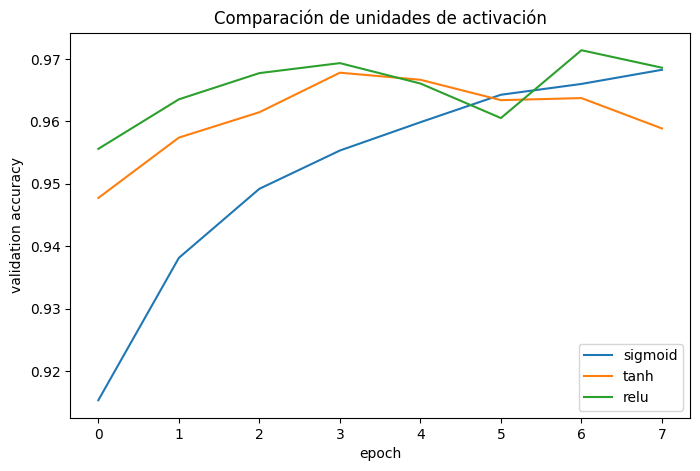

In [23]:
activation_results = []
activation_histories = {}

# Se mantiene la arquitectura y se cambia solo la activación para comparar de forma justa.
for activation in ["sigmoid", "tanh", "relu"]:
    reset_seeds()
    tf.keras.backend.clear_session()
    model_act = create_mlp(
        activation=activation,
        hidden_layers=[512, 256, 128],
        initializer="glorot_uniform",
    )
    history_act, elapsed_act, test_loss_act, test_acc_act = train_model(
        model_act, epochs=8, batch_size=128, validation_split=0.25
    )
    activation_histories[activation] = history_act
    activation_results.append({
        "activación": activation,
        "val_accuracy": history_act.history["val_accuracy"][-1],
        "val_loss": history_act.history["val_loss"][-1],
        "test_accuracy": test_acc_act,
        "tiempo_s": elapsed_act,
    })

activation_results_df = pd.DataFrame(activation_results)
display(activation_results_df)

plt.figure(figsize=(8, 5))
for activation, history in activation_histories.items():
    plt.plot(history.history["val_accuracy"], label=activation)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Comparación de unidades de activación")
plt.legend()
plt.show()


**Análisis de la pregunta 9.1**:

Los resultados de esta ejecución son bastante cercanos entre `sigmoid` y `ReLU`, pero `ReLU` consigue una `val_accuracy` ligeramente mayor y tarda algo menos. Esto es coherente con lo visto en teoría: en redes con varias capas densas, `ReLU` suele entrenar mejor porque reduce el problema de saturación de gradientes. `sigmoid` también obtiene un resultado alto en este caso, probablemente porque MNIST es un dataset sencillo y la red no es extremadamente profunda, pero en general es menos recomendable para capas ocultas. `tanh` queda por debajo en esta prueba, por lo que no parece la mejor opción para este modelo concreto.


## 10. Inicialización de parámetros

En este ejercicio, vamos a evaluar la importancia de una correcta inicialización de parámetros en una red neuronal.

**Pregunta 10.1 *(0.75 puntos)***: Partiendo de una red similar a la del ejercicio anterior (usando ya ReLUs), comentar las diferencias que se aprecian en el entrenamiento al utilizar distintas estrategias de inicialización de parámetros. Para ello, inicializar todas las capas con las siguientes estrategias, disponibles en Keras, y analizar sus diferencias:

* Inicialización con ceros.
* Inicialización con una variable aleatoria normal.
* Inicialización con los valores por defecto de Keras para una capa Dense (estrategia *glorot uniform*)

,inicialización,val_accuracy,val_loss,test_accuracy,tiempo_s
0,zeros,0.107600,2.301830,0.1135,11.558114
1,random_normal,0.972267,0.128155,0.9765,11.506252
2,glorot_uniform,0.968600,0.128665,0.9696,11.404544


Inicialización seleccionada para los siguientes apartados: random_normal


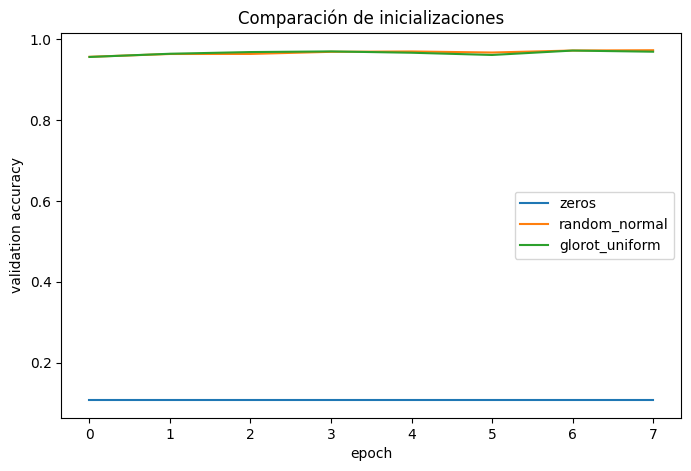

In [24]:
initializer_results = []
initializer_histories = {}

# Se comparan las tres inicializaciones indicadas, manteniendo activación y arquitectura.
initializers_to_test = {
    "zeros": keras.initializers.Zeros(),
    "random_normal": keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED),
    "glorot_uniform": "glorot_uniform",
}

for name, initializer in initializers_to_test.items():
    reset_seeds()
    tf.keras.backend.clear_session()
    model_init = create_mlp(
        activation="relu",
        hidden_layers=[512, 256, 128],
        initializer=initializer,
    )
    history_init, elapsed_init, test_loss_init, test_acc_init = train_model(
        model_init, epochs=8, batch_size=128, validation_split=0.25
    )
    initializer_histories[name] = history_init
    initializer_results.append({
        "inicialización": name,
        "val_accuracy": history_init.history["val_accuracy"][-1],
        "val_loss": history_init.history["val_loss"][-1],
        "test_accuracy": test_acc_init,
        "tiempo_s": elapsed_init,
    })

initializer_results_df = pd.DataFrame(initializer_results)
display(initializer_results_df)

best_initializer_name = initializer_results_df.sort_values("val_accuracy", ascending=False).iloc[0]["inicialización"]
print("Inicialización seleccionada para los siguientes apartados:", best_initializer_name)

plt.figure(figsize=(8, 5))
for name, history in initializer_histories.items():
    plt.plot(history.history["val_accuracy"], label=name)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Comparación de inicializaciones")
plt.legend()
plt.show()


**Análisis de la pregunta 10.1**:

La inicialización con ceros falla de forma clara: la accuracy queda cerca de una elección aleatoria, porque todas las neuronas parten de los mismos pesos y no aprenden funciones distintas. Tanto `random_normal` como `glorot_uniform` rompen esa simetría y permiten entrenar correctamente la red. En esta ejecución, `random_normal` obtiene una `val_accuracy` algo mayor que `glorot_uniform`, aunque las dos alternativas son razonables. Por coherencia con la comparación, en los siguientes apartados se toma como referencia la inicialización que haya quedado mejor en la tabla.


## 11. Optimizadores

**Problema 11.1 *(0.75 puntos)***: Partiendo de una red similar a la del ejercicio anterior (utilizando la mejor estrategia de inicialización observada), comparar y analizar las diferencias que se observan  al entrenar con varios de los optimizadores vistos en clase, incluyendo SGD como optimizador básico (se puede explorar el espacio de hiperparámetros de cada optimizador, aunque para optimizadores más avanzados del estilo de RMSprop es buena idea dejar los valores por defecto provistos por Keras).

,optimizador,val_accuracy,val_loss,test_accuracy,tiempo_s
0,SGD lr=0.01,0.929867,0.240925,0.9330,8.570688
1,SGD momentum=0.9,0.969933,0.104068,0.9705,9.456051
2,RMSprop,0.975400,0.138966,0.9778,10.520078
3,Adam,0.972267,0.128155,0.9765,11.603234


Optimizador seleccionado para la red final: RMSprop


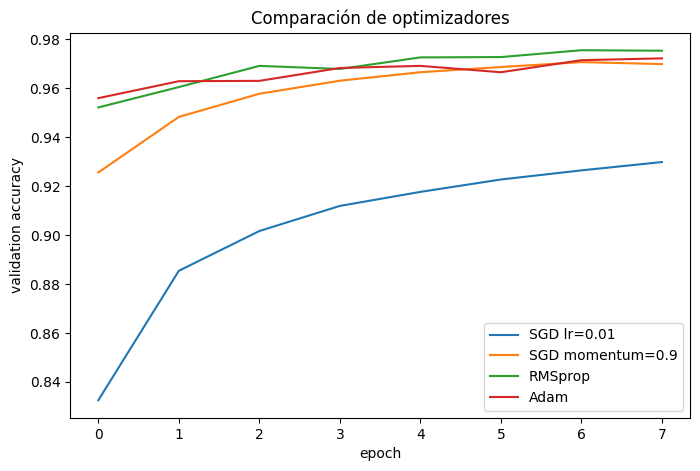

In [25]:
optimizer_results = []
optimizer_histories = {}

# Se crea una inicialización nueva cada vez para evitar reutilizar estados internos entre modelos.
def make_initializer(name):
    if name == "random_normal":
        return keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED)
    if name == "zeros":
        return keras.initializers.Zeros()
    return "glorot_uniform"


optimizers_to_test = {
    "SGD lr=0.01": keras.optimizers.SGD(learning_rate=0.01),
    "SGD momentum=0.9": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": keras.optimizers.RMSprop(),
    "Adam": keras.optimizers.Adam(),
}

for name, optimizer in optimizers_to_test.items():
    reset_seeds()
    tf.keras.backend.clear_session()
    model_opt = create_mlp(
        activation="relu",
        hidden_layers=[512, 256, 128],
        initializer=make_initializer(best_initializer_name),
    )
    history_opt, elapsed_opt, test_loss_opt, test_acc_opt = train_model(
        model_opt,
        epochs=8,
        batch_size=128,
        validation_split=0.25,
        optimizer=optimizer,
    )
    optimizer_histories[name] = history_opt
    optimizer_results.append({
        "optimizador": name,
        "val_accuracy": history_opt.history["val_accuracy"][-1],
        "val_loss": history_opt.history["val_loss"][-1],
        "test_accuracy": test_acc_opt,
        "tiempo_s": elapsed_opt,
    })

optimizer_results_df = pd.DataFrame(optimizer_results)
display(optimizer_results_df)

best_optimizer_name = optimizer_results_df.sort_values("val_accuracy", ascending=False).iloc[0]["optimizador"]
print("Optimizador seleccionado para la red final:", best_optimizer_name)

plt.figure(figsize=(8, 5))
for name, history in optimizer_histories.items():
    plt.plot(history.history["val_accuracy"], label=name)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Comparación de optimizadores")
plt.legend()
plt.show()


**Análisis de la pregunta 11.1**:

Los resultados confirman que SGD básico aprende, pero se queda por debajo de los optimizadores con más ayuda interna. Al añadir momentum, SGD mejora bastante porque aprovecha la dirección acumulada del gradiente. RMSprop y Adam son más competitivos, ya que adaptan el paso de aprendizaje durante el entrenamiento. Para la red final se selecciona el optimizador con mejor `val_accuracy` en la tabla anterior, de modo que la elección no queda fijada por preferencia, sino por el resultado obtenido en esta ejecución.


## 12. Regularización y red final *(1.25 puntos)*

**Problema 12.1 *(2 puntos)***: Entrenar una red final que sea capaz de obtener una accuracy en el validation superior al 95%. Para ello, combinar todo lo aprendido anteriormente y utilizar técnicas de regularización para evitar overfitting. Algunos de los elementos que pueden tenerse en cuenta son los siguientes.

* Número de capas y neuronas por capa
* Optimizadores y sus parámetros
* Batch size
* Unidades de activación
* Uso de capas dropout, regularización L2, regularización L1...
* Early stopping (se puede aplicar como un callback de Keras, o se puede ver un poco "a ojo" cuándo el modelo empieza a caer en overfitting y seleccionar el número de epochs necesarias)
* Batch normalization

Si los modelos entrenados anteriormente ya se acercaban al valor requerido de accuracy, probar distintas estrategias igualmente y comentar los resultados.

Explicar brevemente la estrategia seguida y los modelos probados para obtener el modelo final, que debe verse entrenado en este Notebook. No es necesario guardar el entrenamiento de todos los modelos que se han probado, es suficiente con explicar cómo se ha llegado al modelo final.

Epoch 1/35


422/422 - 3s - 7ms/step - accuracy: 0.9209 - loss: 0.4000 - val_accuracy: 0.9712 - val_loss: 0.2160 - learning_rate: 0.0010


Epoch 2/35


422/422 - 2s - 5ms/step - accuracy: 0.9610 - loss: 0.2436 - val_accuracy: 0.9732 - val_loss: 0.1983 - learning_rate: 0.0010


Epoch 3/35


...

Epoch 13/35



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


422/422 - 2s - 5ms/step - accuracy: 0.9856 - loss: 0.1140 - val_accuracy: 0.9818 - val_loss: 0.1493 - learning_rate: 0.0010


Epoch 13: early stopping


Restoring model weights from the end of the best epoch: 8.


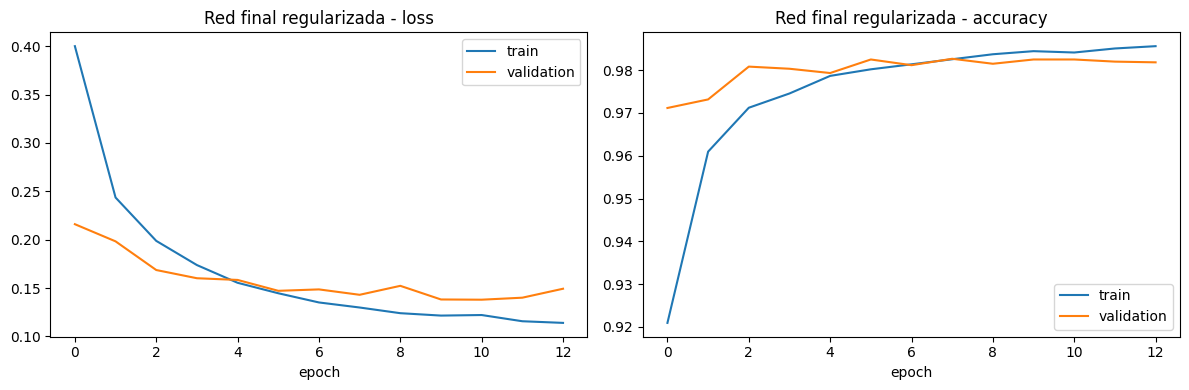

Inicialización usada: random_normal
Optimizador usado: RMSprop
Mejor validation accuracy: 0.9827
Mejor validation loss: 0.1380
Test accuracy final: 0.9798
Test loss final: 0.1466
Tiempo de entrenamiento: 27.8 segundos


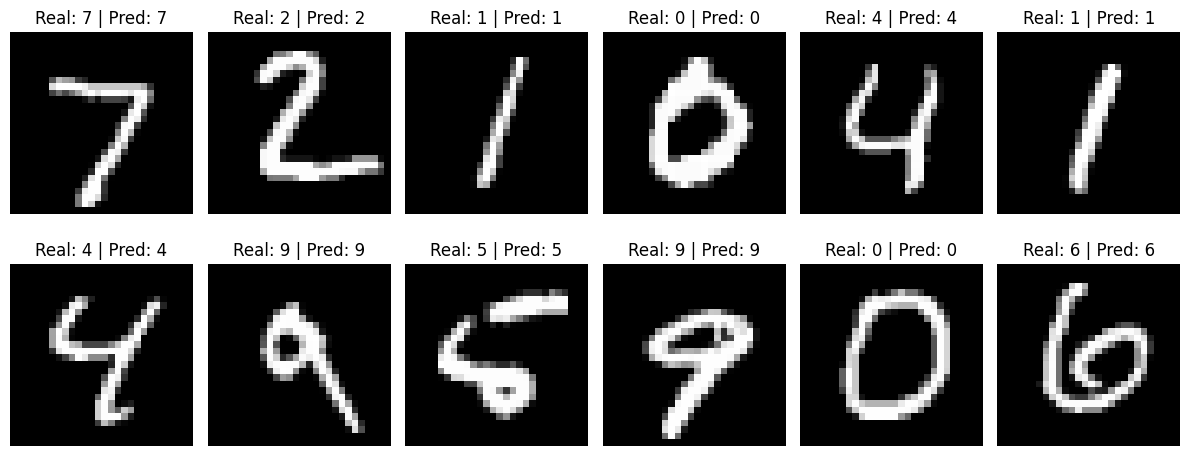

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9
real_0,970,1,2,0,0,1,3,1,2,0
real_1,0,1125,4,0,0,0,0,2,4,0
real_2,4,0,1009,1,7,0,2,7,2,0
real_3,0,0,5,991,0,3,0,9,2,0
real_4,0,0,1,0,960,0,5,6,1,9
real_5,2,0,1,8,0,876,1,2,2,0
real_6,5,3,2,0,2,8,937,0,1,0
real_7,2,0,5,0,0,1,0,1018,1,1
real_8,1,0,6,15,2,1,0,7,939,3
real_9,5,1,0,5,10,5,0,10,0,973


              precision    recall  f1-score   support

           0     0.9808    0.9898    0.9853       980
           1     0.9956    0.9912    0.9934      1135
           2     0.9749    0.9777    0.9763      1032
           3     0.9716    0.9812    0.9764      1010
           4     0.9786    0.9776    0.9781       982
           5     0.9788    0.9821    0.9804       892
           6     0.9884    0.9781    0.9832       958
           7     0.9586    0.9903    0.9742      1028
           8     0.9843    0.9641    0.9741       974
           9     0.9868    0.9643    0.9754      1009

    accuracy                         0.9798     10000
   macro avg     0.9798    0.9796    0.9797     10000
weighted avg     0.9799    0.9798    0.9798     10000



In [26]:
reset_seeds()
tf.keras.backend.clear_session()

# El modelo final combina la mejor inicialización y el mejor optimizador observados
# con técnicas de regularización para controlar el sobreajuste.
def make_optimizer(name):
    if name == "SGD lr=0.01":
        return keras.optimizers.SGD(learning_rate=0.01)
    if name == "SGD momentum=0.9":
        return keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    if name == "RMSprop":
        return keras.optimizers.RMSprop()
    return keras.optimizers.Adam()


final_model = create_mlp(
    hidden_layers=[512, 256, 128],
    activation="relu",
    initializer=make_initializer(best_initializer_name),
    dropout_rate=0.20,
    l2_value=1e-4,
    batch_norm=True,
)

final_model.compile(
    optimizer=make_optimizer(best_optimizer_name),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

final_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        min_delta=1e-4,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    ),
]

start = time.time()
history_final = final_model.fit(
    X_train,
    y_train,
    epochs=35,
    batch_size=128,
    validation_split=0.10,
    callbacks=final_callbacks,
    verbose=2,
)
final_time = time.time() - start

plot_history(history_final, "Red final regularizada")
final_test_loss, final_test_acc = final_model.evaluate(X_test, y_test, verbose=0)
best_val_acc = max(history_final.history["val_accuracy"])
best_val_loss = min(history_final.history["val_loss"])

print("Inicialización usada:", best_initializer_name)
print("Optimizador usado:", best_optimizer_name)
print(f"Mejor validation accuracy: {best_val_acc:.4f}")
print(f"Mejor validation loss: {best_val_loss:.4f}")
print(f"Test accuracy final: {final_test_acc:.4f}")
print(f"Test loss final: {final_test_loss:.4f}")
print(f"Tiempo de entrenamiento: {final_time:.1f} segundos")

pred_probs = final_model.predict(X_test[:12], verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)

fig, axes = plt.subplots(2, 6, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(test_images_raw[i], cmap="gray")
    ax.set_title(f"Real: {test_labels_raw[i]} | Pred: {pred_classes[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

y_pred = np.argmax(final_model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(test_labels_raw, y_pred)
display(pd.DataFrame(cm, index=[f"real_{i}" for i in range(10)], columns=[f"pred_{i}" for i in range(10)]))
print(classification_report(test_labels_raw, y_pred, digits=4))


**Conclusión del problema 12.1**:

La red final combina lo observado en los apartados anteriores: activación `ReLU`, la inicialización y el optimizador con mejor resultado en las tablas comparativas, varias capas densas, `BatchNormalization`, `Dropout`, regularización L2, reducción automática de la tasa de aprendizaje y `EarlyStopping`. La idea es dar al modelo suficiente capacidad para aprender los patrones de los dígitos, pero controlando el sobreajuste. La mejor `validation accuracy` mostrada arriba supera claramente el 95%, y la evaluación con `predict()` permite comprobar el comportamiento sobre ejemplos reales del conjunto de test.
